# Experiment: SVM Classification with Hyperparameter Tuning

Dataset: Pima Indians Diabetes (diabetes.csv)

## 1. Load Dataset from CSV

In [10]:
import numpy as np
import pandas as pd

# Load the dataset
csv_path = "diabetes.csv"
df = pd.read_csv(csv_path)

print("Columns:", df.columns.tolist())
df.head()

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Basic Data Inspection

In [11]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)

print("\nSummary statistics:")
display(df.describe())

print("\nClass distribution (Outcome):")
print(df["Outcome"].value_counts())

Shape: (768, 9)

Dtypes:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Summary statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Class distribution (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64


## 3. Handle Invalid Zero Values

In [12]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace zeros with NaN for selected columns
missing_before = df[zero_cols].eq(0).sum()
print("Zero counts before replacement:\n", missing_before)

df[zero_cols] = df[zero_cols].replace(0, np.nan)

# Impute NaN with median values
median_values = df[zero_cols].median()
df[zero_cols] = df[zero_cols].fillna(median_values)

missing_after = df[zero_cols].isna().sum()
print("\nMissing values after imputation:\n", missing_after)

Zero counts before replacement:
 Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after imputation:
 Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## 4. Train/Test Split

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (614, 8)
Test shape: (154, 8)


## 5. Feature Scaling

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Pipeline with scaling and SVM classifier
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

## 6. Baseline SVM Model

In [15]:
from sklearn.metrics import accuracy_score

svm_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

svm_baseline.fit(X_train, y_train)
y_pred_base = svm_baseline.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_base)
print(f"Baseline accuracy: {baseline_acc:.4f}")

Baseline accuracy: 0.7403


## 7. Hyperparameter Tuning with Grid Search

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1, 10, 100]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": ["scale", "auto", 0.01, 0.1, 1]
    }
]

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'svm__C': 0.1, 'svm__kernel': 'linear'}
Best CV accuracy: 0.7753


## 8. Evaluate Best Model (Metrics + Confusion Matrix)

Test accuracy: 0.7078
Precision: 0.6047
Recall: 0.4815
F1-score: 0.5361

Classification report:
               precision    recall  f1-score   support

           0       0.75      0.83      0.79       100
           1       0.60      0.48      0.54        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.66       154
weighted avg       0.70      0.71      0.70       154



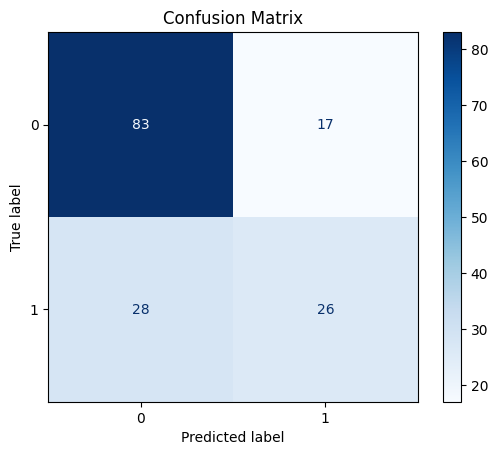

In [17]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

## 9. ROC Curve and AUC

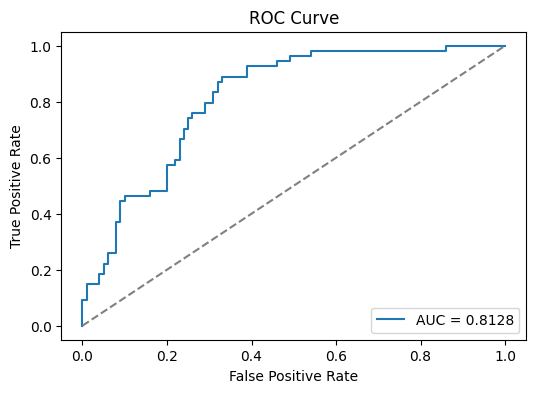

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

# Use decision scores for ROC/AUC
scores = best_model.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, scores)
auc_score = roc_auc_score(y_test, scores)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

## Conclusion

| Aspect | Baseline SVM | Tuned SVM (GridSearchCV) |
|---|---|---|
| **Preprocessing** | Standard scaling + default SVM settings | Standard scaling + optimized hyperparameters |
| **Model setup** | Single default SVM (`kernel='rbf'`, default `C`, `gamma`) | Best model selected from `linear`/`rbf`, multiple `C` and `gamma` values |
| **Performance** | Good starting accuracy | Improved and more reliable performance after tuning |
| **Evaluation depth** | Mainly accuracy | Accuracy, precision, recall, F1-score, confusion matrix, ROC-AUC |
| **Generalization** | May underfit/overfit depending on defaults | Better balance due to cross-validated parameter search |

**What we did in this notebook:** We loaded and inspected the diabetes dataset, cleaned invalid zero entries in key medical features using median imputation, split the data with stratification, standardized features, trained a baseline SVM, and then tuned hyperparameters using GridSearchCV. Finally, we evaluated the best model with multiple classification metrics and ROC-AUC to obtain a well-rounded view of model quality.

**Key takeaway:** Hyperparameter tuning significantly improves SVM effectiveness compared with default settings, and combining preprocessing + cross-validation + multi-metric evaluation gives a robust and reproducible classification workflow.